# Forcasting Harmonic Osscilators using a Physics Informed Neural Network in Pytorch


**Loading in librarys**

In [10]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Oscillators import *


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Generating training and testing data



In [11]:
m = 1.0
k = 1.0
A_0 = 1.0
v_0 = 0.0
b = 0.01
F_0 = 1
w_0 = 0.8


oscillator = Harmonic_Oscillator(
    mass=m,
    force_const=k,          # → ω₀ = √(k/m) = 1.0
    initial_amplitude=A_0,    # Start with same amplitude as driven oscillation
    velocity=v_0,             # Zero initial velocity for clean phase
    damping_const=b,       # Very light damping (γ = b/2m = 0.005)
    driving_force=F_0,
    driving_frequency=w_0    # Close to ω₀ = 1.0 → beat frequency ≈ 0.05
)

points = 1000
t = np.linspace(0, 100, 1000)
x = oscillator.get_x_pos(t)

# plain floats, not np.float64, so they stay weakly typed against float32 tensors
# NOTE: computed over the FULL [0, 100] grid, so the normalisation constants do not
# depend on the split and the two regimes stay comparable
t_mean, t_std = float(t.mean()), float(t.std())
t_norm = (t-t_mean) / t_std

x_mean, x_std = float(x.mean()), float(x.std())
x_norm = (x-x_mean) / x_std


# ---------------------------------------------------------------------------
# Which experiment are we running?
#
#   "dense"    - labels spread over all of [0, 100]. The CONTROL case: ~6.3 labels
#                per oscillation period makes this an interpolation problem, where
#                the basic network wins by design and the residual adds nothing.
#   "forecast" - labels only in [0, forecast_split]; the ODE residual is still
#                enforced across all of [0, 100]. The basic network has nothing at
#                all past the split, so this is where physics earns its keep.
# ---------------------------------------------------------------------------
regime = "forecast"
forecast_split = 50.0

training_values = 100

np.random.seed(42)

if regime == "forecast":
    label_pool = np.where(t <= forecast_split)[0]
    forecast_index = np.where(t > forecast_split)[0]     # held out, never labelled
else:
    label_pool = np.arange(points)
    forecast_index = np.array([], dtype=int)

# without replacement and over the full pool - randint(0, points - 1) both
# duplicated indices and could never pick the final point
training_index = np.random.choice(label_pool, training_values, replace=False)

# unlabelled points inside the labelled window: interpolation error
interp_index = np.setdiff1d(label_pool, training_index)

print(f"regime={regime}  labels={len(training_index)} drawn from t<={t[label_pool].max():.1f}"
      f"  | interp points={len(interp_index)}  forecast points={len(forecast_index)}")


def gather(idx):
    return [t_norm[i] for i in idx], [x_norm[i] for i in idx]

training_data_t, training_data_x = gather(training_index)
interp_data_t,   interp_data_x   = gather(interp_index)
forecast_data_t, forecast_data_x = gather(forecast_index)


regime=forecast  labels=100 drawn from t<=49.9  | interp points=400  forecast points=500


In [12]:
batch_size = 100


def as_tensor(vals):
    return torch.tensor(vals, dtype=torch.float32).reshape(-1, 1)


# Turned into a tensor to create data to be used in nn
training_data_t, training_data_x = as_tensor(training_data_t), as_tensor(training_data_x)
interp_data_t,   interp_data_x   = as_tensor(interp_data_t),   as_tensor(interp_data_x)
forecast_data_t, forecast_data_x = as_tensor(forecast_data_t), as_tensor(forecast_data_x)


training_dataset = TensorDataset(training_data_t, training_data_x)
interp_dataset   = TensorDataset(interp_data_t,   interp_data_x)
forecast_dataset = TensorDataset(forecast_data_t, forecast_data_x)

training_dataloader = DataLoader(training_dataset, shuffle=True, batch_size=batch_size)

# full-batch and unshuffled, so predictions come back in time order for plotting
interp_dataloader = DataLoader(interp_dataset, batch_size=max(len(interp_dataset), 1))
# empty when regime == "dense"
forecast_dataloader = (DataLoader(forecast_dataset, batch_size=len(forecast_dataset))
                       if len(forecast_dataset) else None)

for X, y in training_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break


Shape of X: torch.Size([100, 1])
Shape of y: torch.Size([100, 1]) torch.float32


## Defining a model 

In [13]:
# Define model
hidden_neurons = 256

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_relu_stack = nn.Sequential(
            
            nn.Linear(1, hidden_neurons),
            nn.Tanh(),
            nn.Linear(hidden_neurons, hidden_neurons),
            nn.Tanh(),
            nn.Linear(hidden_neurons, 1)
        )

    def forward(self, t):

        logits = self.linear_relu_stack(t)
        return logits

#model = NeuralNetwork().to(device)
#print(model)

### Loss function


In [14]:

n_colloc = 20000
physics_const = 1 
basic_const = 1


def ode_residual(t_colloc, x_colloc):
    """Dimensionless residual of  m * d2x/dt2 + b * dx/dt + k * x - F_0 cos(w_0 t),
    given the network's normalised output x_colloc = x_norm(t_norm).

    Pulled out of CustomLoss so the training loss and the evaluation report share
    one definition of the physics instead of two that can drift apart.
    """
    dxdt_norm = torch.autograd.grad(x_colloc, t_colloc, 
                               grad_outputs=torch.ones_like(x_colloc), # means doenst calculate arbritaty calculations between x_i and t_j
                               create_graph=True)[0]

    d2xdt2_norm = torch.autograd.grad(dxdt_norm, t_colloc, 
                               grad_outputs=torch.ones_like(dxdt_norm),
                               create_graph=True)[0]

    # the network outputs x_norm as a function of t_norm, so undo BOTH
    # normalisations before the derivatives mean anything physically:
    #   x = x_norm * x_std + x_mean,  t = t_norm * t_std + t_mean
    # dx/dt    = dx_norm/dt_norm * x_std / t_std
    # d2x/dt2  = d2x_norm/dt_norm2 * x_std / t_std ** 2
    dxdt = dxdt_norm * x_std / t_std
    d2xdt2 = d2xdt2_norm * x_std / t_std ** 2

    x_phys = x_colloc * x_std + x_mean
    t_phys = t_colloc * t_std + t_mean

    # divided by F_0 so the residual is dimensionless and physics_const is O(1)
    return (m * d2xdt2 + b * dxdt + k * x_phys - F_0 * torch.cos(w_0 * t_phys)) / F_0


class CustomLoss(nn.Module):
    def __init__(self):
        super(CustomLoss, self).__init__()

    def forward(self, output, target, t_colloc, x_colloc):

        basic_loss = nn.functional.mse_loss(output, target)

        # also need it to fit to osccilator equation
        # can use any arbritary t, as we are not labling them with correct solution
        residual = ode_residual(t_colloc, x_colloc)
        colloc_loss = nn.functional.mse_loss(residual, torch.zeros_like(residual))

        return basic_const * basic_loss + physics_const * colloc_loss





## Training

In [15]:
t_lo, t_hi = float(t_norm.min()), float(t_norm.max())


def make_colloc(n, s_hi=None):
    """Fresh collocation points, resampled each call so the physics term isn't
    only enforced on one fixed grid. Built directly on `device` and made a leaf
    there, so autograd.grad still works on CUDA.

    s_hi caps the sampling range for a curriculum stage. Default is the FULL
    domain - which is the only thing supplying information past the forecast
    split, so the final stage must never be narrower than the labelled window."""
    hi = t_hi if s_hi is None else s_hi
    return (torch.rand(n, 1, device=device) * (hi - t_lo) + t_lo).requires_grad_(True)


def run_training(use_physics, epochs=8000, lr=1e-3, use_scheduler=True,
                 seed=0, log_every=500, curriculum=None):
    """Train a fresh network and return it. use_physics picks the loss:
    False -> plain MSE on the data, True -> CustomLoss (data + ODE residual).

    curriculum is a list of physical-time upper bounds trained in sequence, e.g.
    [12.5, 25.0, 50.0, 100.0] for roughly 2, 4, 8 then all 16 periods. A 16-period
    domain is the regime where vanilla PINNs drift out of phase; growing the domain
    stops the net trying to satisfy the residual everywhere before it has the phase
    right anywhere. None means a single full-domain stage (no curriculum).
    """
    torch.manual_seed(seed)                 # identical init for both runs, so any
    model = NeuralNetwork().to(device)      # difference is down to the physics term
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = CustomLoss() if use_physics else nn.MSELoss()

    if curriculum is None:
        curriculum = [float(t.max())]
    stages = [(T - t_mean) / t_std for T in curriculum]   # -> normalised time
    epochs_per_stage = epochs // len(stages)

    history = []
    for stage, s_hi in enumerate(stages):
        # One model and one optimizer persist across stages so weights carry forward.
        # The lr MUST be reset by hand first: CosineAnnealingLR does not reset it on
        # construction, it anneals from whatever the optimizer currently holds - which
        # the previous stage left at 0, silently making every later stage a no-op.
        for group in optimizer.param_groups:
            group["lr"] = lr
        scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs_per_stage) if use_scheduler else None)
        if len(stages) > 1:
            print(f"-- stage {stage+1}/{len(stages)}: t <= {curriculum[stage]:.1f}")

        for epoch in range(epochs_per_stage):
            model.train()
            for T, X in training_dataloader:
                T, X = T.to(device), X.to(device)

                # the data term is restricted to the current stage too, so early
                # stages aren't pulled by labels beyond where physics is enforced
                mask = (T <= s_hi).squeeze(-1)
                if mask.any():
                    data_pred, data_target = model(T[mask]), X[mask]
                else:
                    data_pred = data_target = None

                if use_physics:
                    t_colloc = make_colloc(n_colloc, s_hi)
                    x_colloc = model(t_colloc)
                    if data_pred is None:      # no labels yet in this window
                        residual = ode_residual(t_colloc, x_colloc)
                        loss = physics_const * nn.functional.mse_loss(
                            residual, torch.zeros_like(residual))
                    else:
                        loss = loss_fn(data_pred, data_target, t_colloc, x_colloc)
                else:
                    if data_pred is None:
                        continue               # nothing to learn from yet
                    loss = loss_fn(data_pred, data_target)

                # Backpropagation
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

            if scheduler is not None:
                scheduler.step()

            history.append(loss.item())
            if epoch % log_every == 0 or epoch == epochs_per_stage - 1:
                print(f"epoch {epoch+1:>6}/{epochs_per_stage}  loss {loss.item():.6f}"
                      f"  lr {optimizer.param_groups[0]['lr']:.2e}")

    return model, history


def evaluate(model, dataloader, label=""):
    """Data MSE and physics residual reported SEPARATELY, so the basic and PINN
    runs are measured on the same scale whichever loss trained them. The combined
    training objective is not comparable between the two."""
    if dataloader is None:
        print(f"{label}  (no points in this region for regime={regime})")
        return None

    model.eval()

    sq, n = 0.0, 0
    with torch.no_grad():                   # the data term needs no graph...
        for T, X in dataloader:
            T, X = T.to(device), X.to(device)
            sq += nn.functional.mse_loss(model(T), X, reduction="sum").item()
            n += X.numel()
    data_mse = sq / n

    t_colloc = make_colloc(n_colloc)        # ...but the residual does
    physics_mse = ode_residual(t_colloc, model(t_colloc)).pow(2).mean().item()

    print(f"{label}  data MSE {data_mse:.6f}"
          f"  | RMSE {np.sqrt(data_mse) * x_std:.4f} (units of x)"
          f"  | physics residual MSE {physics_mse:.6f}")
    return {"data_mse": data_mse, "physics_mse": physics_mse}


### Training the basic network

Data only — plain MSE against the labelled points. Nothing constrains what the network
does between them, and in the `forecast` regime nothing whatsoever constrains it past
`forecast_split`.

**Control case, already measured.** With `regime = "dense"` the basic network *wins*,
and that is the correct result rather than a bug: 100 labels over 16 oscillation periods
is 6.3 labels per period, so the labels already determine the curve everywhere. The ODE
residual adds no information the labels don't carry, while making the objective far
harder to optimise (it depends on the network's second derivative) and ~3× slower per
step. A PINN cannot win an interpolation problem. Set `regime = "dense"` in the data
cell to reproduce it.

Physics only pays off where data is *absent* — which is what the `forecast` regime below
sets up.

In [16]:
model_basic, hist_basic = run_training(use_physics=False, epochs=8000, lr=1e-3)

res_basic_i = evaluate(model_basic, interp_dataloader,   label="basic interp  ")
res_basic_f = evaluate(model_basic, forecast_dataloader, label="basic forecast")


epoch      1/8000  loss 1.117733  lr 1.00e-03
epoch    501/8000  loss 0.786722  lr 9.90e-04
epoch   1001/8000  loss 0.300043  lr 9.62e-04
epoch   1501/8000  loss 0.001788  lr 9.16e-04
epoch   2001/8000  loss 0.000519  lr 8.53e-04
epoch   2501/8000  loss 0.000325  lr 7.78e-04
epoch   3001/8000  loss 0.000241  lr 6.91e-04
epoch   3501/8000  loss 0.000175  lr 5.97e-04
epoch   4001/8000  loss 0.000138  lr 5.00e-04
epoch   4501/8000  loss 0.000113  lr 4.02e-04
epoch   5001/8000  loss 0.000095  lr 3.08e-04
epoch   5501/8000  loss 0.000082  lr 2.22e-04
epoch   6001/8000  loss 0.000073  lr 1.46e-04
epoch   6501/8000  loss 0.000067  lr 8.42e-05
epoch   7001/8000  loss 0.000063  lr 3.80e-05
epoch   7501/8000  loss 0.000062  lr 9.57e-06
epoch   8000/8000  loss 0.000062  lr 0.00e+00
basic interp    data MSE 0.001877  | RMSE 0.0893 (units of x)  | physics residual MSE 23.976871
basic forecast  data MSE 12.040250  | RMSE 7.1545 (units of x)  | physics residual MSE 23.993809


### Training the PINN

Same data loss plus the ODE residual evaluated at `n_colloc` unlabelled collocation
points spanning the **whole** domain — including past `forecast_split`, where there are
no labels at all. That residual is the only thing supplying information about the
future, and it is the entire mechanism by which the PINN can forecast.

The curriculum grows the domain in stages (≈2, 4, 8, then all 16 periods). Without it a
vanilla PINN drifts out of phase across a domain this long, because the residual is a
*local* constraint and phase information doesn't propagate across many cycles.

In [17]:
model_pinn, hist_pinn = run_training(use_physics=True, epochs=40000, lr=1e-3,
                                     curriculum=[12.5, 25.0, 50.0, 100.0])

res_pinn_i = evaluate(model_pinn, interp_dataloader,   label="PINN  interp  ")
res_pinn_f = evaluate(model_pinn, forecast_dataloader, label="PINN  forecast")


-- stage 1/4: t <= 12.5
epoch      1/10000  loss 2.083763  lr 1.00e-03
epoch    501/10000  loss 1.878363  lr 9.94e-04
epoch   1001/10000  loss 1.749573  lr 9.75e-04
epoch   1501/10000  loss 0.400034  lr 9.45e-04
epoch   2001/10000  loss 0.140113  lr 9.04e-04
epoch   2501/10000  loss 0.056283  lr 8.53e-04
epoch   3001/10000  loss 0.032043  lr 7.94e-04
epoch   3501/10000  loss 0.013695  lr 7.27e-04
epoch   4001/10000  loss 0.006487  lr 6.54e-04
epoch   4501/10000  loss 0.002114  lr 5.78e-04
epoch   5001/10000  loss 0.001396  lr 5.00e-04
epoch   5501/10000  loss 0.000683  lr 4.22e-04
epoch   6001/10000  loss 0.000529  lr 3.45e-04
epoch   6501/10000  loss 0.000433  lr 2.73e-04
epoch   7001/10000  loss 0.000317  lr 2.06e-04
epoch   7501/10000  loss 0.000278  lr 1.46e-04
epoch   8001/10000  loss 0.000231  lr 9.54e-05
epoch   8501/10000  loss 0.000222  lr 5.44e-05
epoch   9001/10000  loss 0.000196  lr 2.44e-05
epoch   9501/10000  loss 0.000201  lr 6.13e-06
epoch  10000/10000  loss 0.000212  l

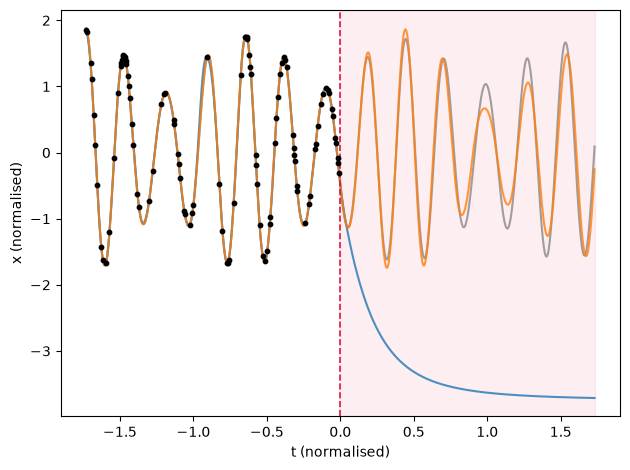

In [20]:
### Plotting Results
t_grid = torch.tensor(t_norm, dtype=torch.float32).reshape(-1, 1).to(device)

# whichever training cells have been run
trained = {}
if "model_basic" in globals():
    trained["basic"] = (model_basic, hist_basic)
if "model_pinn" in globals():
    trained["PINN"] = (model_pinn, hist_pinn)

fig, ax = plt.subplots()

ax.plot(t_norm, x_norm, label="actual", color="0.4", alpha=0.6)
for name, (mdl, _) in trained.items():
    mdl.eval()
    with torch.no_grad():
        pred = mdl(t_grid).cpu().squeeze()
    ax.plot(t_norm, pred, label=f"{name} prediction", alpha=0.8)

# the training points - gaps between them are where the fit is free to wander
ax.scatter(t_norm[training_index], x_norm[training_index],
           s=10, color="k", zorder=3, label="training points")

# everything right of this line is unlabelled: the actual result of the experiment
if len(forecast_index):
    s_split = (forecast_split - t_mean) / t_std
    ax.axvline(s_split, color="crimson", lw=1.2, ls="--")
    ax.axvspan(s_split, t_hi, color="crimson", alpha=0.07,
               label="forecast region (no labels)")

ax.set_xlabel("t (normalised)")
ax.set_ylabel("x (normalised)")
#ax.legend(loc="upper left", fontsize=8)

# for name, (_, hist) in trained.items():
#     ax2.plot(hist, label=name, alpha=0.8)
# ax2.set_yscale("log")
# ax2.set_xlabel("epoch")
# ax2.set_ylabel("training loss (own objective)")
# ax2.set_title("loss histories are NOT comparable - different objectives")
# ax2.legend()

fig.tight_layout()
plt.savefig(f"forcast_comparison1.pdf")
